Размер датасета: (100, 13)

Типы данных:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Participant ID                 100 non-null    int64  
 1   Age                            100 non-null    int64  
 2   Gender                         100 non-null    str    
 3   Current Weight (lbs)           100 non-null    float64
 4   BMR (Calories)                 100 non-null    float64
 5   Daily Calories Consumed        100 non-null    float64
 6   Daily Caloric Surplus/Deficit  100 non-null    float64
 7   Weight Change (lbs)            100 non-null    float64
 8   Duration (weeks)               100 non-null    int64  
 9   Physical Activity Level        100 non-null    str    
 10  Sleep Quality                  100 non-null    str    
 11  Stress Level                   100 non-null    int64  
 12  Final Weight (lbs)   

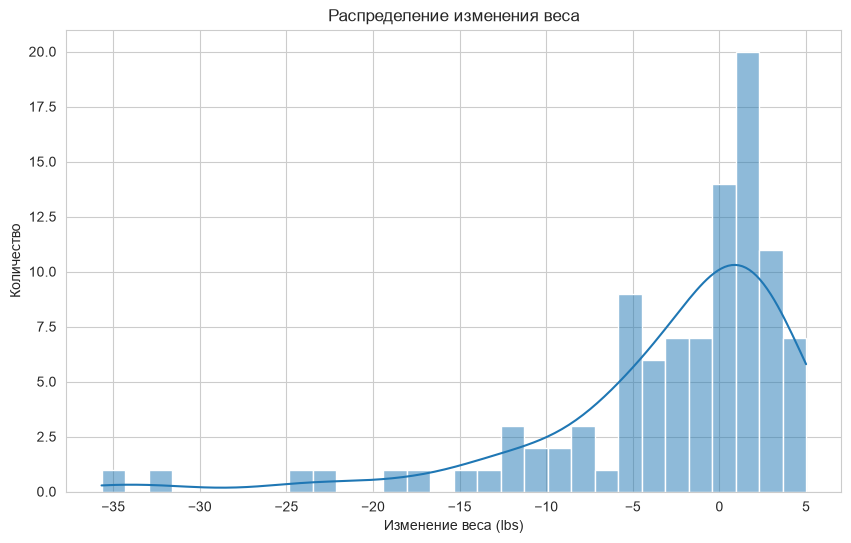

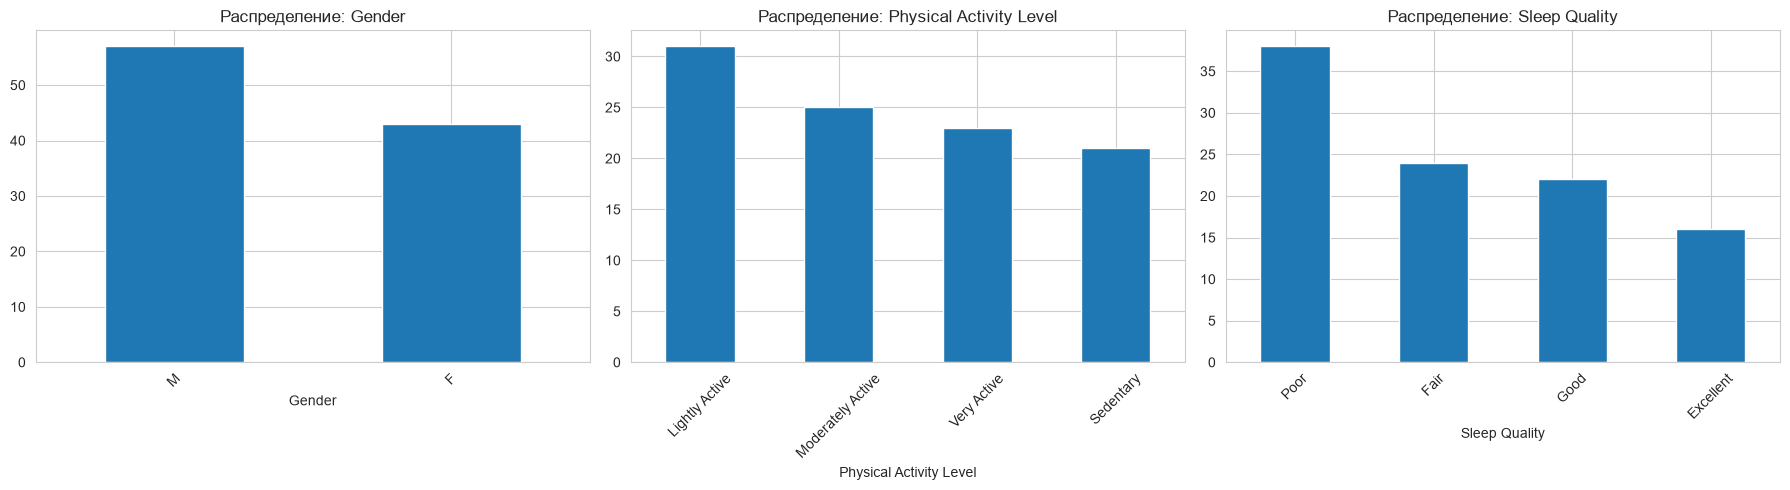

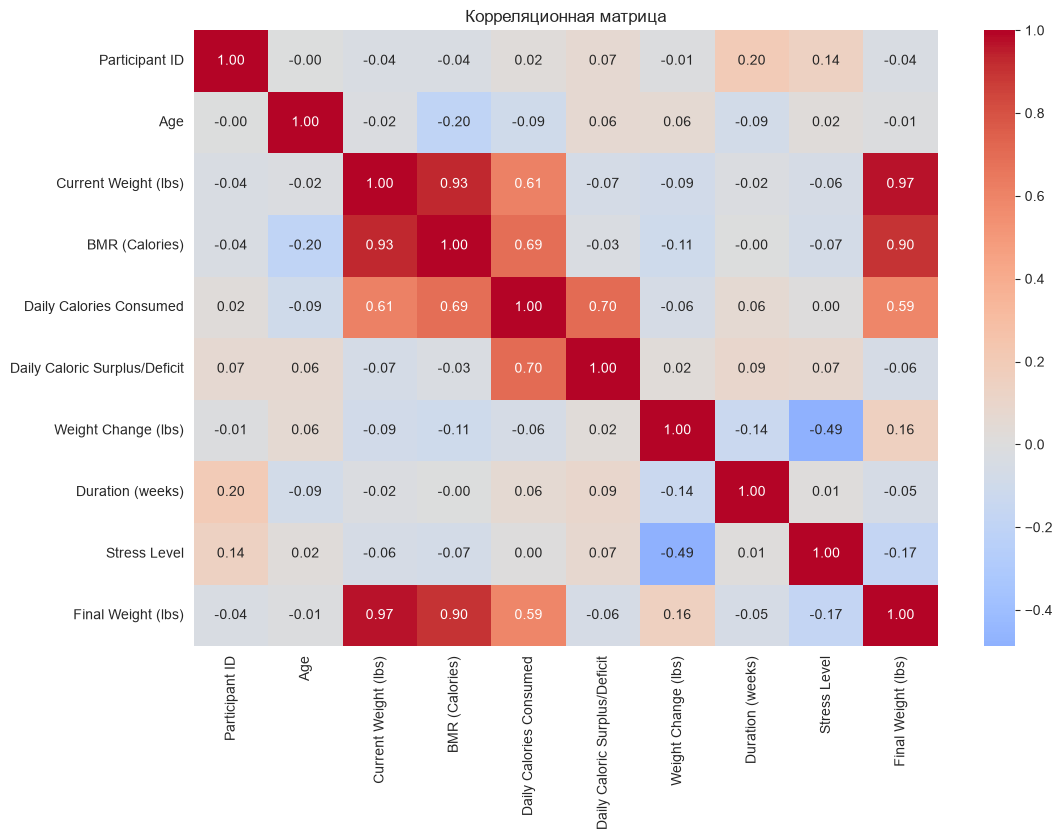

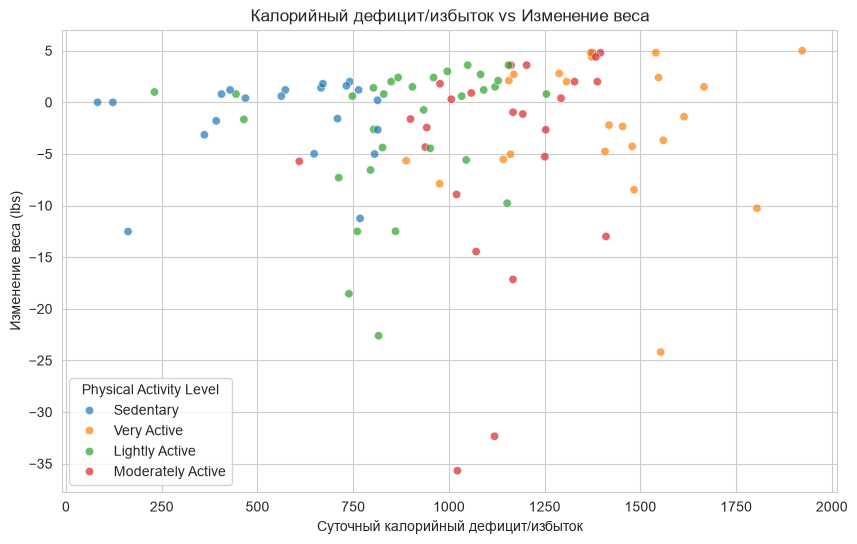

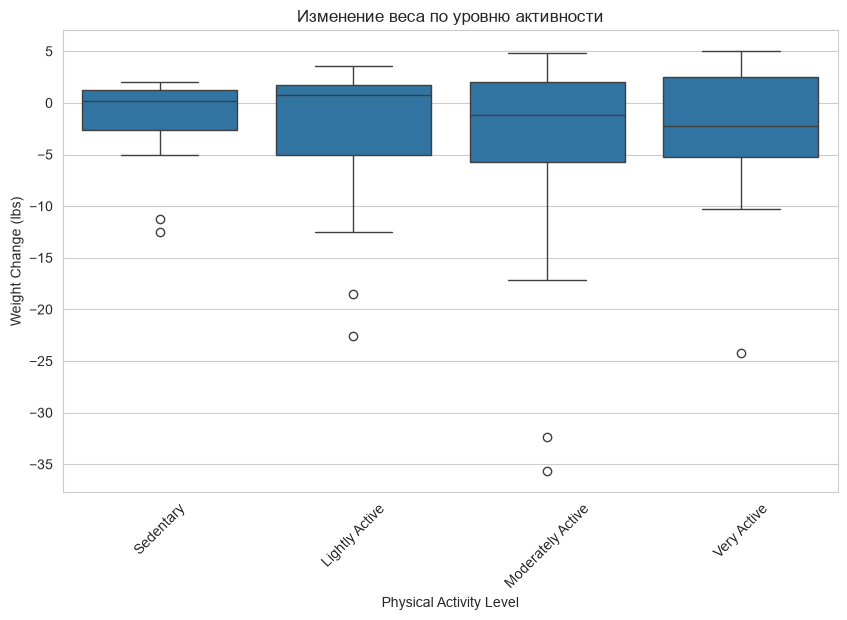

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/raw/weight_change_dataset.csv')
df.head()
print("Размер датасета:", df.shape)
print("\nТипы данных:")
print(df.info())
print("Пропущенные значения:")
print(df.isnull().sum())
print("\nДубликаты:", df.duplicated().sum())
df.describe()

plt.figure(figsize=(10, 6))
sns.histplot(df['Weight Change (lbs)'], kde=True, bins=30)
plt.title('Распределение изменения веса')
plt.xlabel('Изменение веса (lbs)')
plt.ylabel('Количество')
plt.show()

categorical_cols = ['Gender', 'Physical Activity Level', 'Sleep Quality']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Распределение: {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Daily Caloric Surplus/Deficit', y='Weight Change (lbs)', 
                 hue='Physical Activity Level', alpha=0.7)
plt.title('Калорийный дефицит/избыток vs Изменение веса')
plt.xlabel('Суточный калорийный дефицит/избыток')
plt.ylabel('Изменение веса (lbs)')
plt.show()

plt.figure(figsize=(10, 6))
order = ['Sedentary', 'Lightly Active', 'Moderately Active', 'Very Active']
sns.boxplot(data=df, x='Physical Activity Level', y='Weight Change (lbs)', order=order)
plt.title('Изменение веса по уровню активности')
plt.xticks(rotation=45)
plt.show()

## Выводы по EDA
1) Датасет чистый: 100 записей, 13 признаков, пропусков и дубликатов нет
2) Изменение веса у большинства участников близко к 0, но есть выраженные выбросы до -35 lbs
3) Прямая линейная корреляция калорийного дефицита с изменением веса слабая (0.02) - возможно связь нелинейная или зависит от длительности периода(Duration)
4) Неожиданная находка: уровень стресса имеет умеренную отрицательную корреляцию с изменением веса (-0.49)
5) Участники с высокой активностью показывают больший разброс в изменении веса, включая крайние случаи похудения
6) Следующий шаг: предобработка данных (кодирование категориальных признаков, создание новых признаков вроде BMI, обработка выбросов)